<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Visualization_of_Spin_Orbit_Coupling_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!uv pip install --system -q numpy scipy matplotlib k3d ipywidgets

Hydrogenic state controls: Z=1, n=2, l=1, s=0.5
zeta_nl = 0.243485862 cm^-1

      j    2j+1   L.S factor      E_SO/(hc) [cm^-1]       E_SO [meV]
------------------------------------------------------------------------
  0.500       2    -1.000000           -0.243485862    -0.0301883995
  1.500       4     0.500000            0.121742931     0.0150941997
------------------------------------------------------------------------
Degeneracy-weighted centroid = 0.000000e+00 cm^-1
Fine-structure splitting      = 0.365228793 cm^-1


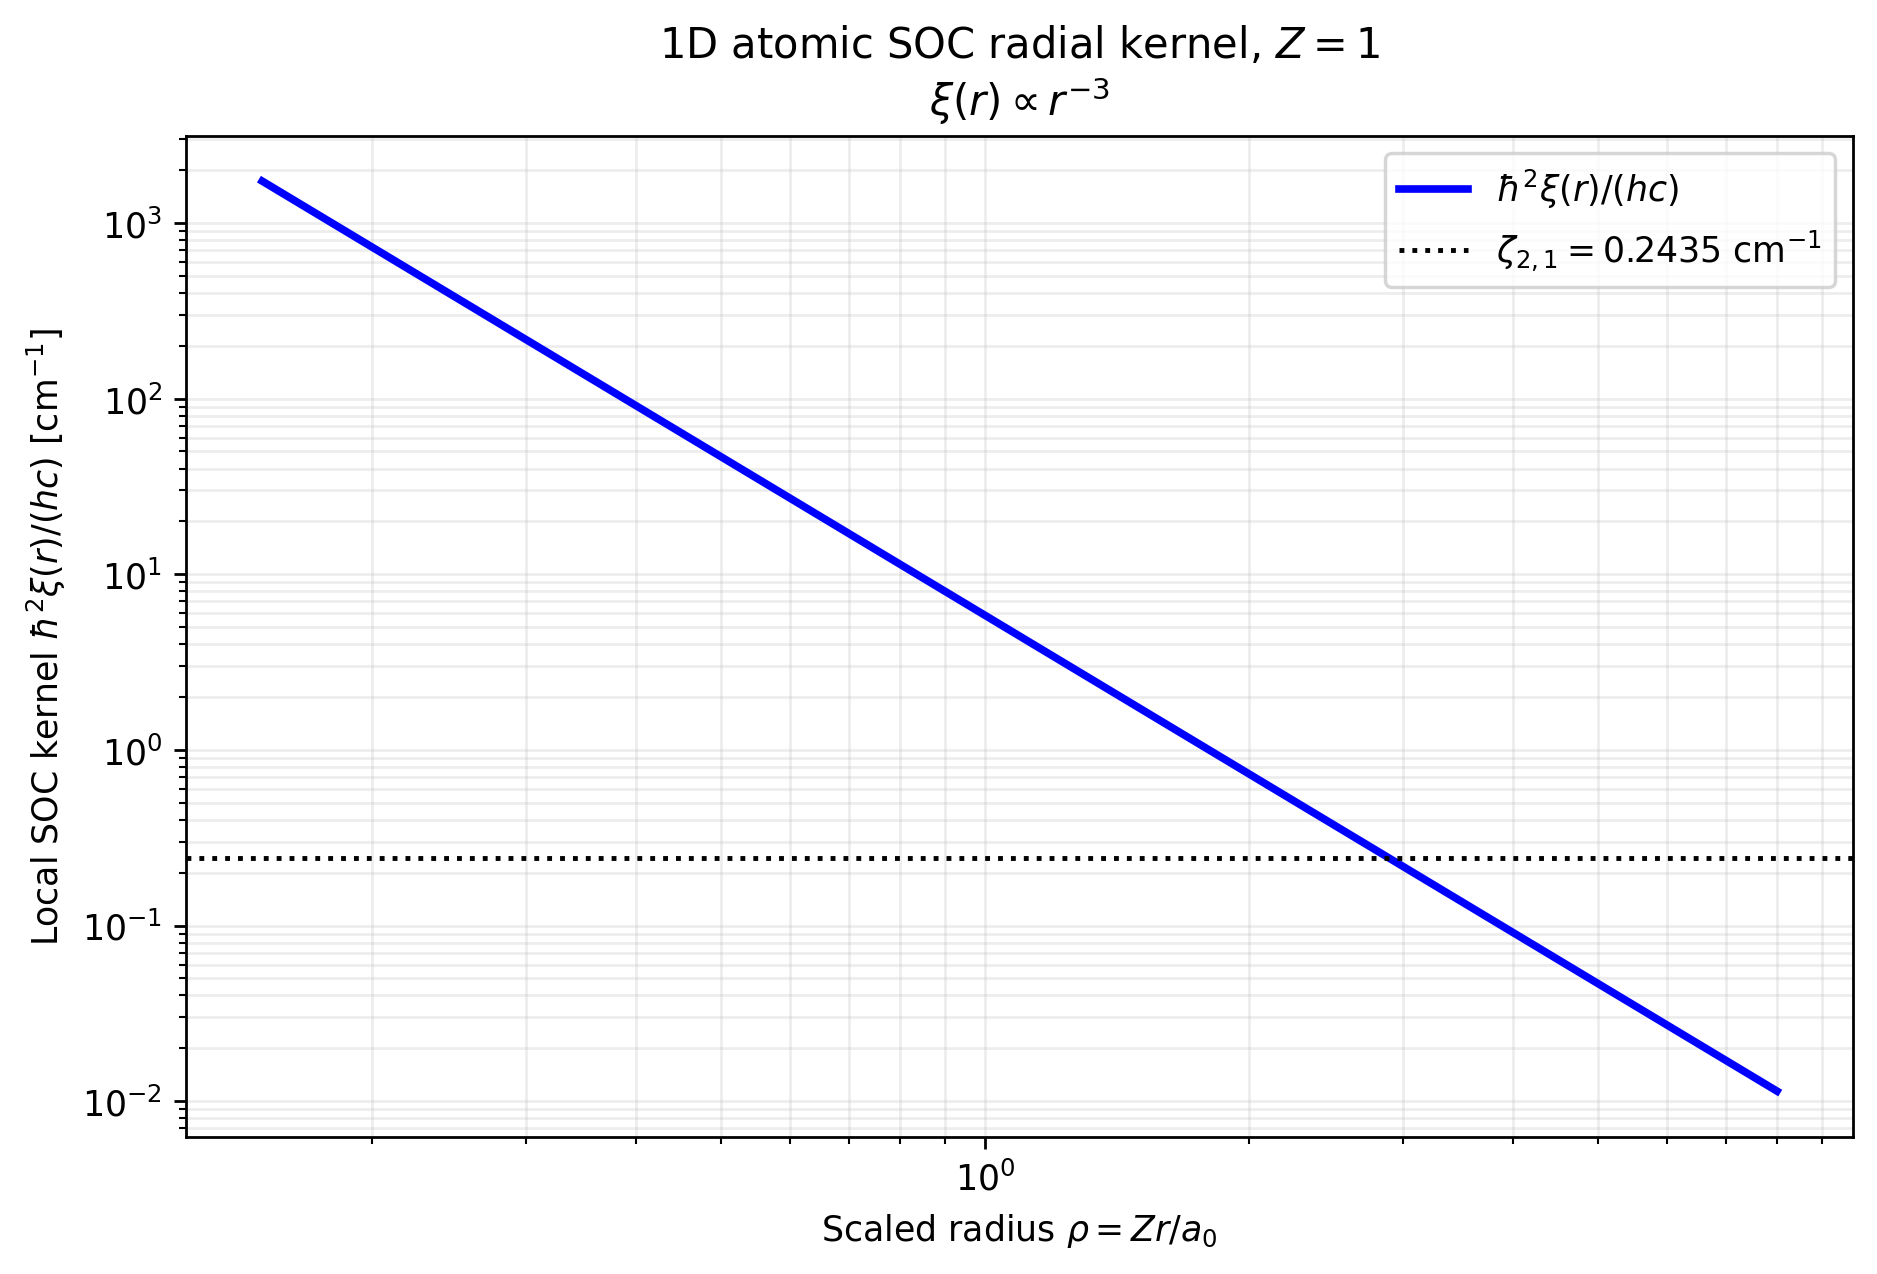

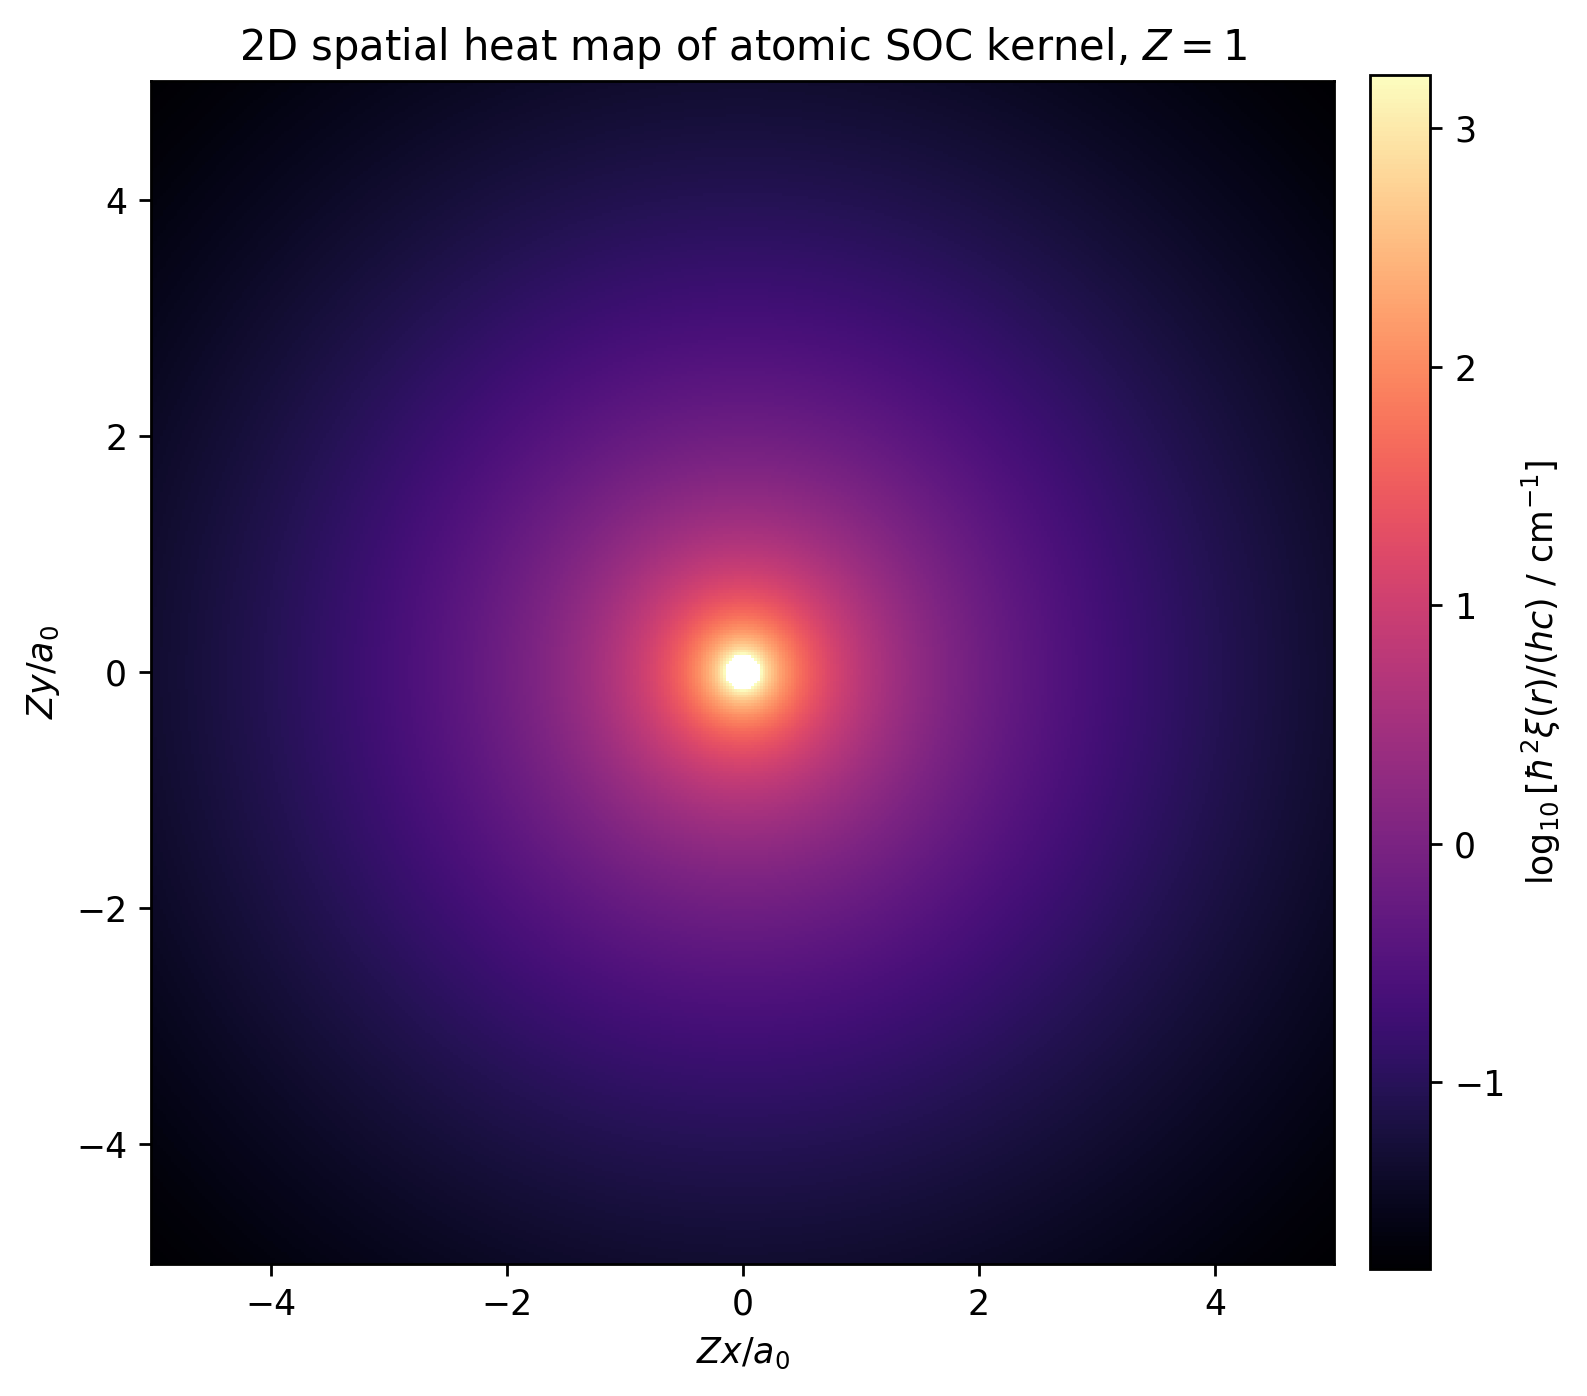

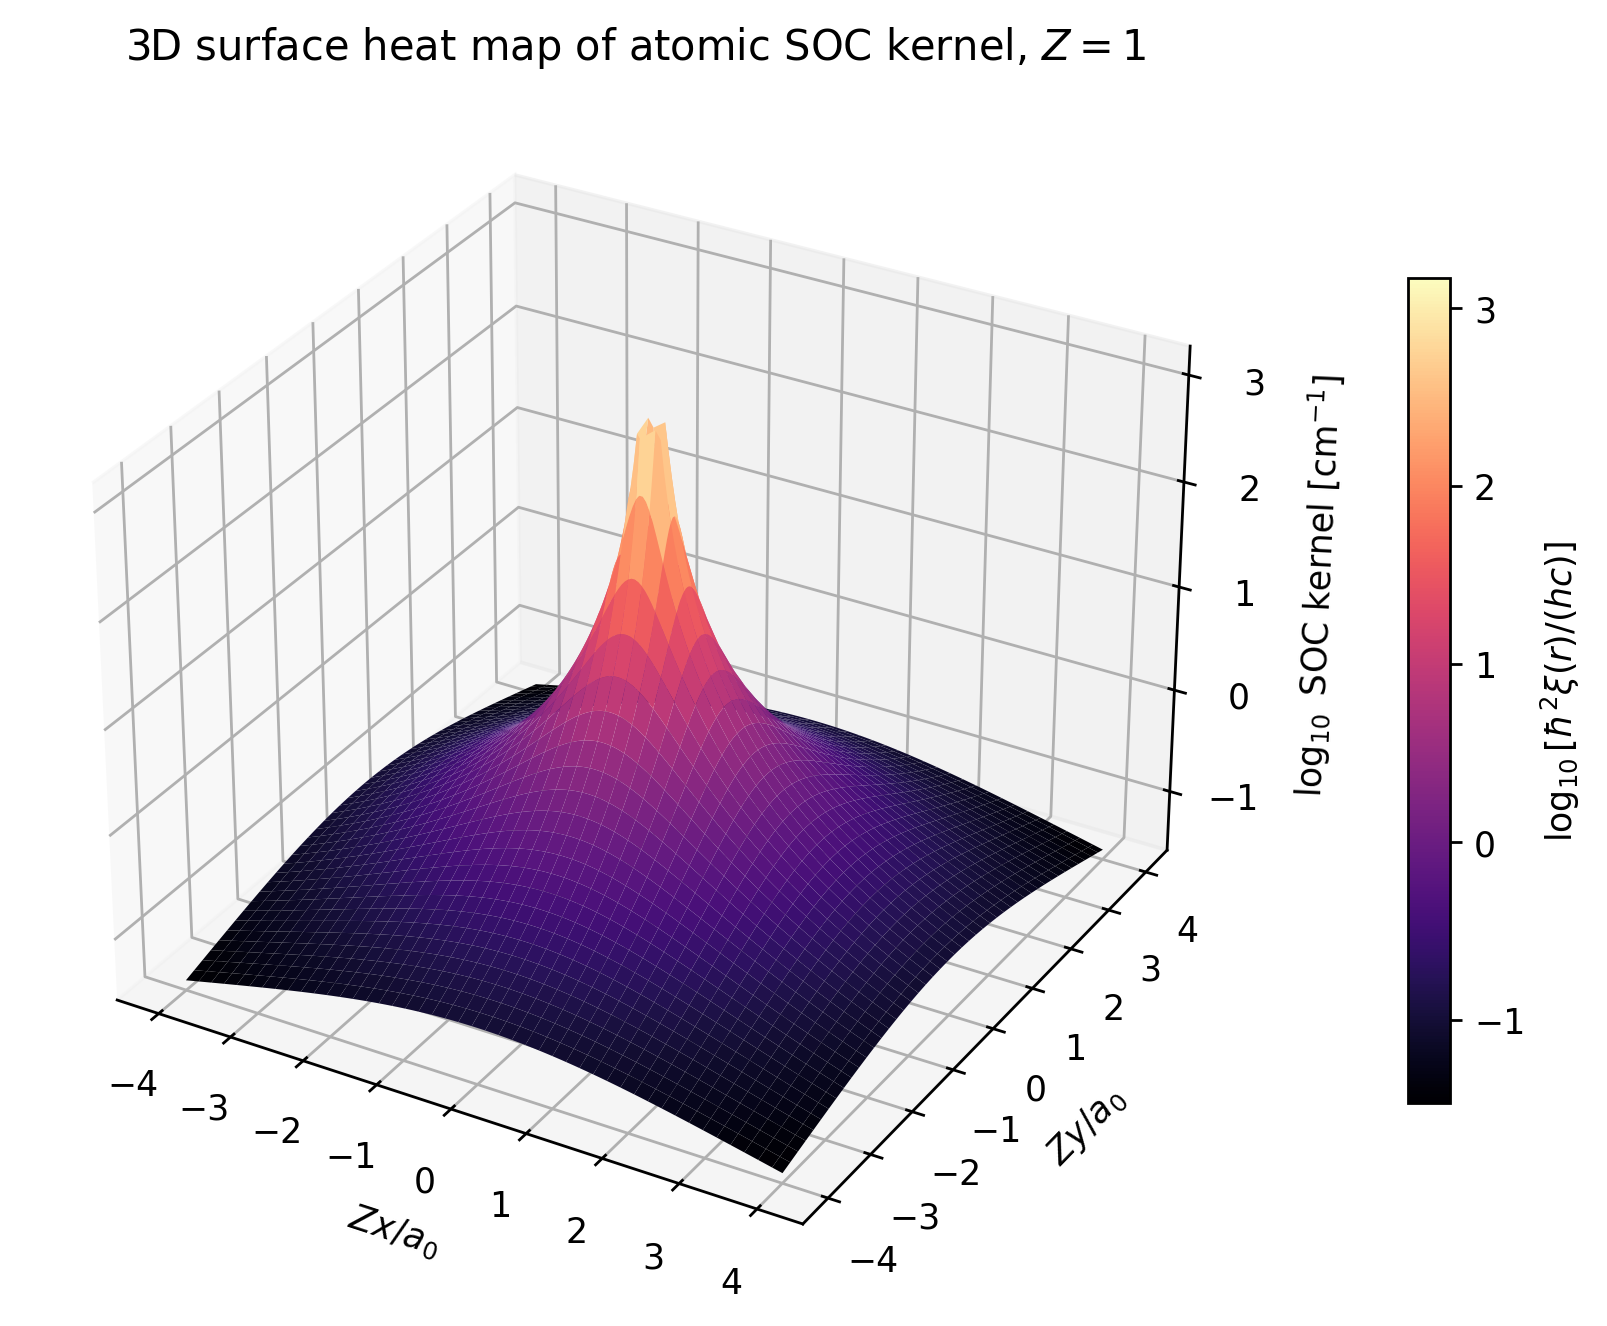

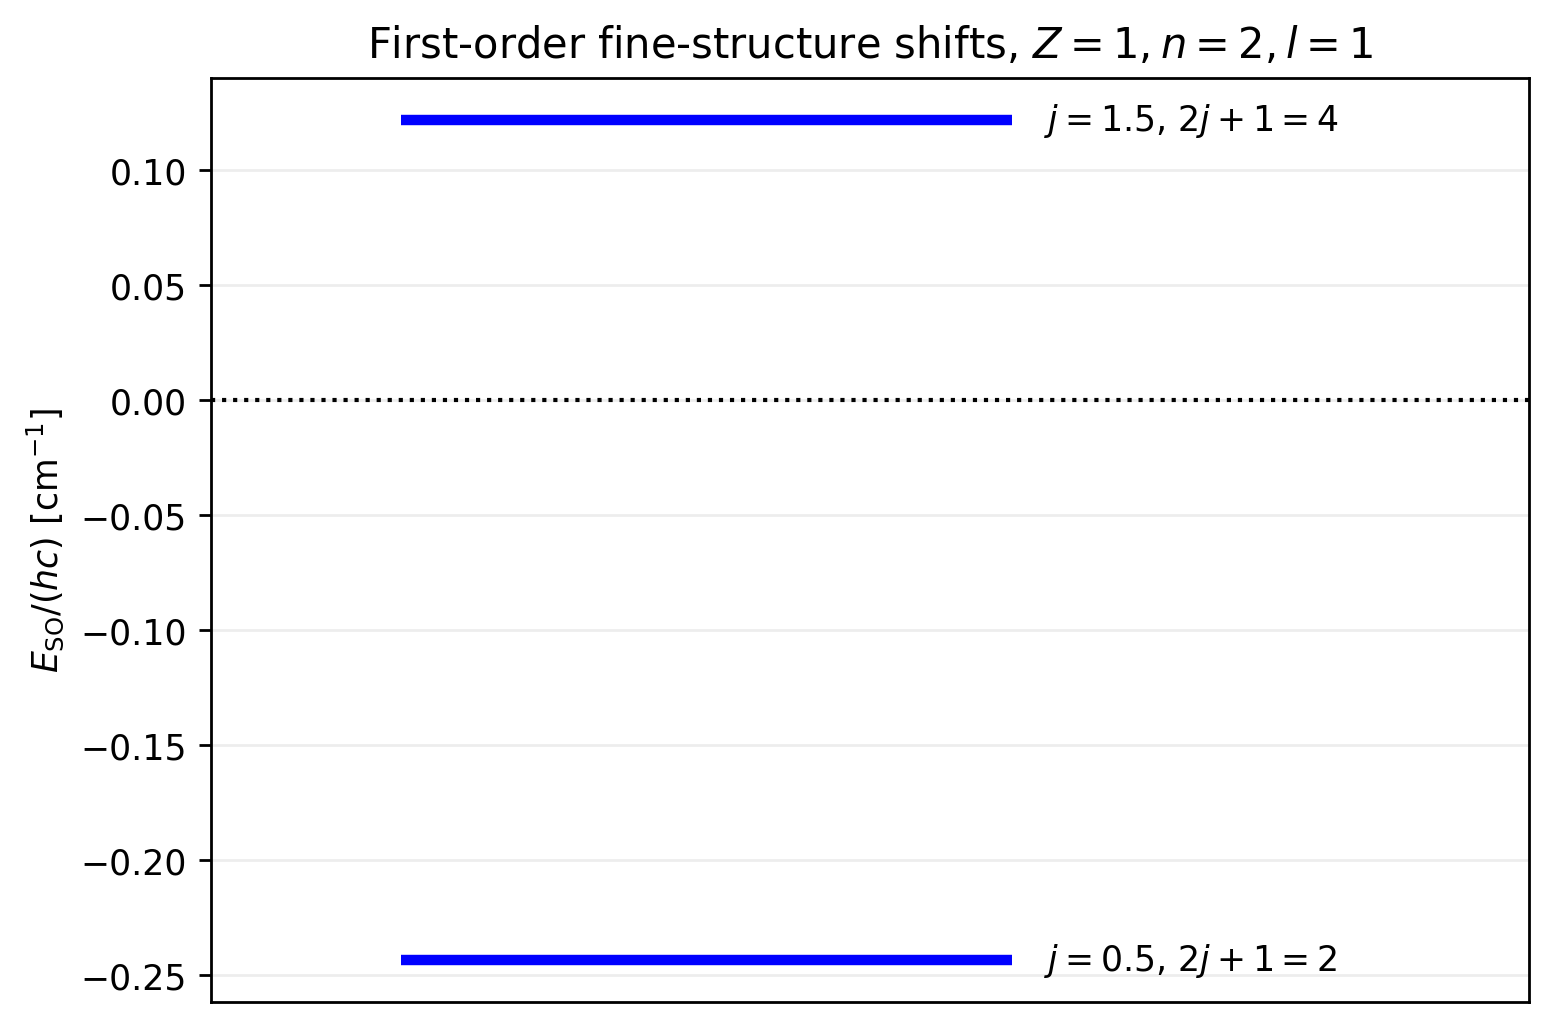

Output()

K3D scalar mapping:
normalized value 0 -> log10 kernel = -1.7552
normalized value 1 -> log10 kernel = 2.9522
Spatial axes use the scaled coordinates Zx/a0, Zy/a0, and Zz/a0.


In [3]:
"""Visualize hydrogenic atomic spin-orbit coupling in 1D, 2D, and 3D."""

import io

import k3d
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from k3d.colormaps import matplotlib_color_maps
from scipy import constants


# ---------------------------------------------------------------------------
# Control knobs
# ---------------------------------------------------------------------------

# Hydrogenic quantum-state controls.
Z = 1
N = 2
L = 1
S = 0.5

# Spatial coordinates use rho = Z * r / a0.
RHO_CORE = 0.15
RHO_MAX_1D = 8.0
RHO_EXTENT_2D = 5.0
RHO_EXTENT_3D = 4.0

# Numerical resolution.
GRID_1D = 1400
GRID_2D = 420
GRID_SURFACE_3D = 180
GRID_VOLUME_3D = 72

# Plot controls.
FIGURE_DPI = 250
COLORMAP = "magma"

SHOW_LEVEL_DIAGRAM = True
SHOW_STATIC_3D_SURFACE = True
SHOW_K3D_VOLUME = True

# K3D volume controls.
K3D_ALPHA_COEF = 35.0
K3D_SAMPLES = 256
K3D_MIN_NORMALIZED = 0.12
K3D_COMPRESSION_LEVEL = 9


# ---------------------------------------------------------------------------
# Matplotlib configuration
# ---------------------------------------------------------------------------

matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["font.weight"] = "normal"
matplotlib.rcParams["figure.dpi"] = FIGURE_DPI
matplotlib.rcParams["savefig.dpi"] = FIGURE_DPI


# ---------------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------------

A0_M = constants.physical_constants["Bohr radius"][0]

H_BAR = constants.hbar
PLANCK_H = constants.h
LIGHT_SPEED = constants.c
E_CHARGE = constants.elementary_charge
EPSILON_0 = constants.epsilon_0
ELECTRON_MASS = constants.m_e
ALPHA = constants.alpha

# scipy.constants.Rydberg is expressed in inverse metres.
RYDBERG_CM = constants.Rydberg / 100.0

# Energy corresponding to one inverse centimetre.
JOULE_PER_CM_INV = PLANCK_H * LIGHT_SPEED * 100.0

# One millielectronvolt expressed in joules.
JOULE_PER_MEV = constants.electron_volt * 1.0e-3


# ---------------------------------------------------------------------------
# Rendering helpers
# ---------------------------------------------------------------------------

def display_figure_in_memory(fig: plt.Figure) -> None:
    """Render a Matplotlib figure from an in-memory PNG buffer.

    Args:
        fig: Matplotlib figure to display.
    """
    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        bbox_inches="tight",
        dpi=FIGURE_DPI,
    )

    buffer.seek(0)

    display(
        Image(
            data=buffer.getvalue(),
        )
    )

    plt.close(fig)


# ---------------------------------------------------------------------------
# Quantum-state validation
# ---------------------------------------------------------------------------

def validate_quantum_numbers(
    z: int,
    n: int,
    l_value: int,
) -> None:
    """Validate hydrogenic quantum-number controls.

    Args:
        z: Nuclear charge number.
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.

    Raises:
        ValueError: If a quantum number lies outside its allowed range.
    """
    if z < 1:
        raise ValueError("Z must be at least 1.")

    if n < 1:
        raise ValueError("N must be at least 1.")

    if l_value < 0 or l_value >= n:
        raise ValueError("L must satisfy 0 <= L < N.")


# ---------------------------------------------------------------------------
# Atomic spin-orbit coupling model
# ---------------------------------------------------------------------------

def scaled_radius_to_meters(
    rho: np.ndarray,
    z: int,
) -> np.ndarray:
    """Convert rho = Z * r / a0 into radius in metres.

    Args:
        rho: Dimensionless scaled radius.
        z: Nuclear charge number.

    Returns:
        Radius in metres.
    """
    return rho * A0_M / z


def xi_coulomb(
    r_m: np.ndarray,
    z: int,
) -> np.ndarray:
    """Evaluate the Coulombic spin-orbit radial coefficient xi(r).

    The hydrogenic Coulomb result is

        xi(r) = Z e^2 /
                (8 pi epsilon_0 m_e^2 c^2 r^3).

    Args:
        r_m: Electron-nucleus radius in metres.
        z: Nuclear charge number.

    Returns:
        Spin-orbit radial coefficient xi(r).
    """
    numerator = z * E_CHARGE**2

    denominator = (
        8.0
        * np.pi
        * EPSILON_0
        * ELECTRON_MASS**2
        * LIGHT_SPEED**2
        * r_m**3
    )

    return numerator / denominator


def soc_kernel_cm_inv(
    r_m: np.ndarray,
    z: int,
) -> np.ndarray:
    """Convert hbar^2 xi(r) into an equivalent wavenumber.

    Args:
        r_m: Radius in metres.
        z: Nuclear charge number.

    Returns:
        Local SOC energy kernel divided by hc in inverse centimetres.
    """
    energy_j = H_BAR**2 * xi_coulomb(
        r_m,
        z,
    )

    return energy_j / JOULE_PER_CM_INV


def zeta_hydrogenic_cm_inv(
    z: int,
    n: int,
    l_value: int,
) -> float:
    """Evaluate the hydrogenic spin-orbit coupling constant zeta_nl.

    The expression is

        zeta_nl =
            alpha^2 R Z^4 /
            [n^3 l (l + 1/2) (l + 1)].

    Args:
        z: Nuclear charge number.
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.

    Returns:
        Spin-orbit coupling constant in inverse centimetres.
    """
    if l_value == 0:
        return 0.0

    denominator = (
        n**3
        * l_value
        * (l_value + 0.5)
        * (l_value + 1.0)
    )

    return (
        ALPHA**2
        * RYDBERG_CM
        * z**4
        / denominator
    )


def angular_factor(
    l_value: int,
    s_value: float,
    j_value: float,
) -> float:
    """Evaluate the L dot S eigenvalue factor divided by hbar^2.

    The dimensionless factor is

        1/2 [
            j(j + 1)
            - l(l + 1)
            - s(s + 1)
        ].

    Args:
        l_value: Orbital angular momentum quantum number.
        s_value: Spin angular momentum quantum number.
        j_value: Total angular momentum quantum number.

    Returns:
        Dimensionless L dot S eigenvalue factor.
    """
    return 0.5 * (
        j_value * (j_value + 1.0)
        - l_value * (l_value + 1.0)
        - s_value * (s_value + 1.0)
    )


def allowed_j_values(
    l_value: int,
    s_value: float = 0.5,
) -> list[float]:
    """Return allowed total angular momentum values.

    Args:
        l_value: Orbital angular momentum quantum number.
        s_value: Electron spin quantum number.

    Returns:
        Allowed values of j in ascending order.
    """
    if l_value == 0:
        return [s_value]

    return [
        l_value - s_value,
        l_value + s_value,
    ]


def first_order_shift_cm_inv(
    z: int,
    n: int,
    l_value: int,
    j_value: float,
    s_value: float = 0.5,
) -> float:
    """Evaluate the first-order spin-orbit energy correction.

    Args:
        z: Nuclear charge number.
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.
        j_value: Total angular momentum quantum number.
        s_value: Spin angular momentum quantum number.

    Returns:
        Spin-orbit energy shift divided by hc in inverse centimetres.
    """
    zeta = zeta_hydrogenic_cm_inv(
        z,
        n,
        l_value,
    )

    factor = angular_factor(
        l_value,
        s_value,
        j_value,
    )

    return zeta * factor


# ---------------------------------------------------------------------------
# Numerical diagnostics
# ---------------------------------------------------------------------------

def report_quantum_levels(
    z: int,
    n: int,
    l_value: int,
) -> None:
    """Print SOC constants and fine-structure level shifts.

    Args:
        z: Nuclear charge number.
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.
    """
    zeta = zeta_hydrogenic_cm_inv(
        z,
        n,
        l_value,
    )

    j_values = allowed_j_values(
        l_value,
        S,
    )

    print(
        "Hydrogenic state controls: "
        f"Z={z}, n={n}, l={l_value}, s={S:g}"
    )

    print(
        f"zeta_nl = {zeta:.9g} cm^-1"
    )

    print()

    print(
        f"{'j':>7} "
        f"{'2j+1':>7} "
        f"{'L.S factor':>12} "
        f"{'E_SO/(hc) [cm^-1]':>22} "
        f"{'E_SO [meV]':>16}"
    )

    print("-" * 72)

    shifts = []
    weights = []

    for j_value in j_values:
        factor = angular_factor(
            l_value,
            S,
            j_value,
        )

        shift_cm = first_order_shift_cm_inv(
            z,
            n,
            l_value,
            j_value,
            S,
        )

        shift_mev = (
            shift_cm
            * JOULE_PER_CM_INV
            / JOULE_PER_MEV
        )

        degeneracy = int(
            round(
                2.0 * j_value + 1.0
            )
        )

        shifts.append(
            shift_cm
        )

        weights.append(
            degeneracy
        )

        print(
            f"{j_value:7.3f} "
            f"{degeneracy:7d} "
            f"{factor:12.6f} "
            f"{shift_cm:22.9g} "
            f"{shift_mev:16.9g}"
        )

    centroid = float(
        np.average(
            shifts,
            weights=weights,
        )
    )

    splitting = float(
        max(shifts) - min(shifts)
    )

    print("-" * 72)

    print(
        "Degeneracy-weighted centroid = "
        f"{centroid:.6e} cm^-1"
    )

    print(
        "Fine-structure splitting      = "
        f"{splitting:.9g} cm^-1"
    )


# ---------------------------------------------------------------------------
# 1D radial visualization
# ---------------------------------------------------------------------------

def plot_radial_soc_1d(
    z: int,
    n: int,
    l_value: int,
) -> None:
    """Plot the Coulombic SOC kernel along the radial coordinate.

    Args:
        z: Nuclear charge number.
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.
    """
    rho = np.geomspace(
        RHO_CORE,
        RHO_MAX_1D,
        GRID_1D,
    )

    radius_m = scaled_radius_to_meters(
        rho,
        z,
    )

    kernel_cm = soc_kernel_cm_inv(
        radius_m,
        z,
    )

    fig, ax = plt.subplots(
        figsize=(8.6, 5.2),
    )

    ax.plot(
        rho,
        kernel_cm,
        linewidth=2.2,
        color="#0000FF",
        label=r"$\hbar^2\xi(r)/(hc)$",
    )

    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )

    ax.set_xlabel(
        r"Scaled radius $\rho=Zr/a_0$"
    )

    ax.set_ylabel(
        r"Local SOC kernel "
        r"$\hbar^2\xi(r)/(hc)$ "
        r"[cm$^{-1}$]"
    )

    ax.set_title(
        rf"1D atomic SOC radial kernel, $Z={z}$"
        "\n"
        r"$\xi(r)\propto r^{-3}$"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.22,
    )

    zeta = zeta_hydrogenic_cm_inv(
        z,
        n,
        l_value,
    )

    if zeta > 0.0:
        ax.axhline(
            zeta,
            linewidth=1.4,
            linestyle=":",
            color="black",
            label=(
                rf"$\zeta_{{{n},{l_value}}}"
                rf"={zeta:.4g}$ cm$^{{-1}}$"
            ),
        )

    ax.legend(
        loc="best"
    )

    display_figure_in_memory(
        fig
    )


# ---------------------------------------------------------------------------
# 2D spatial field
# ---------------------------------------------------------------------------

def spatial_log_kernel_2d(
    z: int,
    extent: float,
    grid_size: int,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Construct a 2D logarithmic SOC kernel field.

    Args:
        z: Nuclear charge number.
        extent: Half-width in scaled coordinates.
        grid_size: Number of samples on each axis.

    Returns:
        X coordinate grid, Y coordinate grid, and log10 SOC kernel.
    """
    axis = np.linspace(
        -extent,
        extent,
        grid_size,
    )

    x_grid, y_grid = np.meshgrid(
        axis,
        axis,
        indexing="xy",
    )

    rho = np.sqrt(
        x_grid**2
        + y_grid**2
    )

    valid = (
        rho >= RHO_CORE
    )

    log_kernel = np.full_like(
        rho,
        np.nan,
        dtype=np.float64,
    )

    radius_m = scaled_radius_to_meters(
        rho[valid],
        z,
    )

    kernel_cm = soc_kernel_cm_inv(
        radius_m,
        z,
    )

    log_kernel[valid] = np.log10(
        kernel_cm
    )

    return (
        x_grid,
        y_grid,
        log_kernel,
    )


def plot_spatial_heatmap_2d(
    z: int,
) -> None:
    """Plot a 2D spatial heat map of the atomic SOC kernel.

    Args:
        z: Nuclear charge number.
    """
    x_grid, y_grid, log_kernel = spatial_log_kernel_2d(
        z,
        RHO_EXTENT_2D,
        GRID_2D,
    )

    fig, ax = plt.subplots(
        figsize=(7.4, 6.2),
    )

    mesh = ax.pcolormesh(
        x_grid,
        y_grid,
        log_kernel,
        shading="auto",
        cmap=COLORMAP,
    )

    ax.set_aspect(
        "equal"
    )

    ax.set_xlabel(
        r"$Zx/a_0$"
    )

    ax.set_ylabel(
        r"$Zy/a_0$"
    )

    ax.set_title(
        rf"2D spatial heat map of atomic SOC kernel, $Z={z}$"
    )

    colorbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
    )

    colorbar.set_label(
        r"$\log_{10}"
        r"[\hbar^2\xi(r)/(hc)"
        r"\ /\ \mathrm{cm}^{-1}]$"
    )

    display_figure_in_memory(
        fig
    )


# ---------------------------------------------------------------------------
# Static 3D surface
# ---------------------------------------------------------------------------

def plot_spatial_surface_3d(
    z: int,
) -> None:
    """Render a static 3D surface representation of the SOC field.

    Args:
        z: Nuclear charge number.
    """
    x_grid, y_grid, log_kernel = spatial_log_kernel_2d(
        z,
        RHO_EXTENT_3D,
        GRID_SURFACE_3D,
    )

    fig = plt.figure(
        figsize=(8.4, 6.4),
    )

    ax = fig.add_subplot(
        111,
        projection="3d",
    )

    surface = ax.plot_surface(
        x_grid,
        y_grid,
        log_kernel,
        cmap=COLORMAP,
        linewidth=0.0,
        antialiased=True,
    )

    ax.set_xlabel(
        r"$Zx/a_0$"
    )

    ax.set_ylabel(
        r"$Zy/a_0$"
    )

    ax.set_zlabel(
        r"$\log_{10}$ SOC kernel [cm$^{-1}$]"
    )

    ax.set_title(
        rf"3D surface heat map of atomic SOC kernel, $Z={z}$"
    )

    colorbar = fig.colorbar(
        surface,
        ax=ax,
        shrink=0.67,
        pad=0.10,
    )

    colorbar.set_label(
        r"$\log_{10}"
        r"[\hbar^2\xi(r)/(hc)]$"
    )

    display_figure_in_memory(
        fig
    )


# ---------------------------------------------------------------------------
# Fine-structure energy levels
# ---------------------------------------------------------------------------

def plot_fine_structure_levels(
    z: int,
    n: int,
    l_value: int,
) -> None:
    """Plot first-order atomic SOC fine-structure energy shifts.

    Args:
        z: Nuclear charge number.
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.
    """
    j_values = allowed_j_values(
        l_value,
        S,
    )

    shifts = [
        first_order_shift_cm_inv(
            z,
            n,
            l_value,
            j_value,
            S,
        )
        for j_value in j_values
    ]

    fig, ax = plt.subplots(
        figsize=(6.8, 4.8),
    )

    ax.axhline(
        0.0,
        linewidth=1.2,
        linestyle=":",
        color="black",
        label="Unsplit centroid",
    )

    for j_value, shift_cm in zip(
        j_values,
        shifts,
    ):
        degeneracy = int(
            round(
                2.0 * j_value + 1.0
            )
        )

        ax.hlines(
            shift_cm,
            0.18,
            0.76,
            linewidth=3.0,
            color="#0000FF",
        )

        ax.text(
            0.79,
            shift_cm,
            (
                rf"$j={j_value:g}$, "
                rf"$2j+1={degeneracy}$"
            ),
            va="center",
            fontsize=10,
        )

    ax.set_xlim(
        0.0,
        1.25,
    )

    ax.set_xticks([])

    ax.set_ylabel(
        r"$E_{\mathrm{SO}}/(hc)$ "
        r"[cm$^{-1}$]"
    )

    ax.set_title(
        rf"First-order fine-structure shifts, "
        rf"$Z={z}, n={n}, l={l_value}$"
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.22,
    )

    display_figure_in_memory(
        fig
    )


# ---------------------------------------------------------------------------
# 3D volumetric field
# ---------------------------------------------------------------------------

def create_k3d_volume_data(
    z: int,
) -> tuple[
    np.ndarray,
    float,
    float,
]:
    """Construct a normalized 3D logarithmic SOC field for K3D.

    Args:
        z: Nuclear charge number.

    Returns:
        Normalized volume, minimum log10 kernel, and maximum log10 kernel.
    """
    axis = np.linspace(
        -RHO_EXTENT_3D,
        RHO_EXTENT_3D,
        GRID_VOLUME_3D,
        dtype=np.float32,
    )

    z_grid, y_grid, x_grid = np.meshgrid(
        axis,
        axis,
        axis,
        indexing="ij",
    )

    rho = np.sqrt(
        x_grid**2
        + y_grid**2
        + z_grid**2
    )

    valid = (
        rho >= RHO_CORE
    )

    log_field = np.full(
        rho.shape,
        np.nan,
        dtype=np.float32,
    )

    radius_m = scaled_radius_to_meters(
        rho[valid].astype(
            np.float64
        ),
        z,
    )

    kernel_cm = soc_kernel_cm_inv(
        radius_m,
        z,
    )

    log_field[valid] = np.log10(
        kernel_cm
    ).astype(
        np.float32
    )

    valid_values = log_field[
        np.isfinite(
            log_field
        )
    ]

    log_min = float(
        np.min(
            valid_values
        )
    )

    log_max = float(
        np.max(
            valid_values
        )
    )

    normalized = np.zeros(
        rho.shape,
        dtype=np.float32,
    )

    normalized[valid] = (
        log_field[valid]
        - log_min
    ) / (
        log_max
        - log_min
    )

    normalized = np.clip(
        normalized,
        0.0,
        1.0,
    )

    normalized[
        normalized
        < K3D_MIN_NORMALIZED
    ] = 0.0

    return (
        normalized,
        log_min,
        log_max,
    )


def show_k3d_soc_volume(
    z: int,
) -> None:
    """Display an interactive K3D volumetric SOC heat map.

    Args:
        z: Nuclear charge number.
    """
    try:
        from google.colab import output as colab_output

        colab_output.enable_custom_widget_manager()
    except ImportError:
        pass

    volume_data, log_min, log_max = create_k3d_volume_data(
        z
    )

    try:
        k3d_colormap = (
            matplotlib_color_maps.Magma
        )
    except AttributeError:
        k3d_colormap = (
            matplotlib_color_maps.Inferno
        )

    extent = RHO_EXTENT_3D

    volume = k3d.volume(
        volume_data,
        color_map=k3d_colormap,
        color_range=[
            0.0,
            1.0,
        ],
        samples=K3D_SAMPLES,
        alpha_coef=K3D_ALPHA_COEF,
        interpolation=True,
        bounds=[
            -extent,
            extent,
            -extent,
            extent,
            -extent,
            extent,
        ],
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Atomic SOC kernel",
    )

    plot = k3d.plot(
        background_color=0xFFFFFF,
        grid_visible=False,
        camera_auto_fit=True,
    )

    plot += volume

    plot.display()

    print(
        "K3D scalar mapping:"
    )

    print(
        "normalized value 0 -> "
        f"log10 kernel = {log_min:.4f}"
    )

    print(
        "normalized value 1 -> "
        f"log10 kernel = {log_max:.4f}"
    )

    print(
        "Spatial axes use the scaled coordinates "
        "Zx/a0, Zy/a0, and Zz/a0."
    )


# ---------------------------------------------------------------------------
# Main execution
# ---------------------------------------------------------------------------

validate_quantum_numbers(
    Z,
    N,
    L,
)

report_quantum_levels(
    Z,
    N,
    L,
)

plot_radial_soc_1d(
    Z,
    N,
    L,
)

plot_spatial_heatmap_2d(
    Z,
)

if SHOW_STATIC_3D_SURFACE:
    plot_spatial_surface_3d(
        Z,
    )

if SHOW_LEVEL_DIAGRAM:
    plot_fine_structure_levels(
        Z,
        N,
        L,
    )

if SHOW_K3D_VOLUME:
    show_k3d_soc_volume(
        Z,
    )

## Example Output from the K3D Viewer

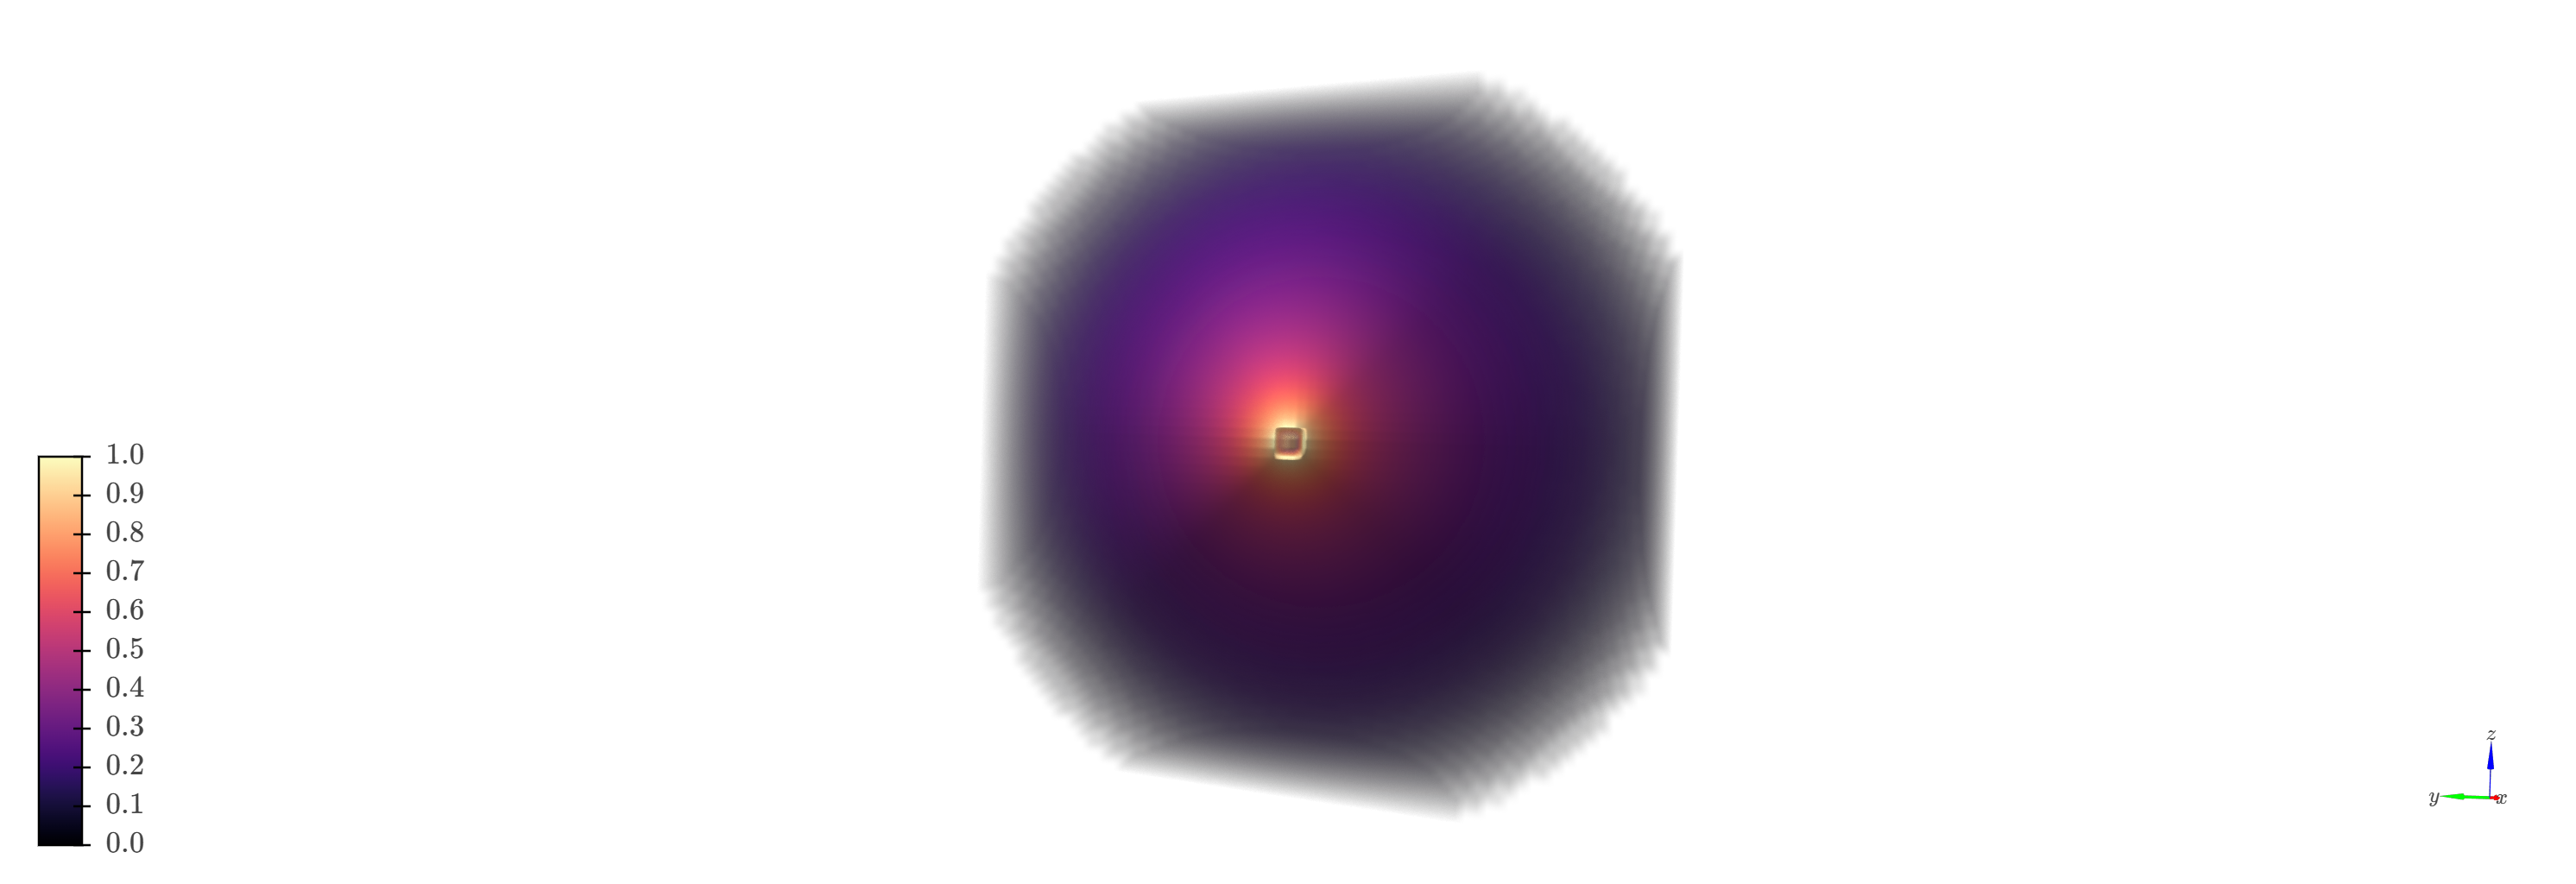